## Implementación de Faster R-CNN

Detección de lomos de libros con Faster R-CNN (*torchvision*, ResNet-50 FPN) sobre *Book Spine 2*. El notebook ajusta el detector y reporta mAP, precisión, recall y tiempo de inferencia.


## Setup — instalación de librerías

La celda siguiente instala en el kernel las dependencias de Faster R-CNN con *torchvision*. Es la única instalación del notebook: no lee *dataset/*, no convierte anotaciones y no ejecuta entrenamiento ni inferencia.

Paquetes y rol:

- *torch* y *torchvision*: modelo, fine-tuning e inferencia.
- *pycocotools*: métricas estilo COCO (mAP, precisión, recall).
- *numpy*, *Pillow*, *opencv-python-headless*: lectura y dibujo de imágenes.
- *matplotlib*: figuras de cajas sobre las imágenes.
- *PyYAML*: lectura de *dataset/data.yaml*.
- *tqdm* y *pandas*: progreso de épocas y tablas de resultados.
- *roboflow*: descarga de *Book Spine 2* cuando *dataset/* no está completo.
- *torchmetrics*: mAP y métricas de detección en validación.

No se incluyen Ultralytics, EasyOCR ni rapidfuzz: esta notebook no los utiliza.

En Google Colab, *torch* y *torchvision* suelen venir preinstalados con GPU; reinstalarlos con *pip* puede dejar el runtime en CPU. En un entorno local, los mismos paquetes constan en *requirements.txt* en la raíz del repositorio.


In [1]:
%pip install -q numpy
%pip install -q Pillow
%pip install -q matplotlib
%pip install -q opencv-python-headless
%pip install -q PyYAML
%pip install -q tqdm
%pip install -q pandas
%pip install -q pycocotools
%pip install -q torch
%pip install -q torchvision
%pip install -q roboflow
%pip install -q torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 100.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.5 MB/s eta 0:00:0000:01


## 2. Dataset Book Spine 2

La celda siguiente deja el export YOLOv8 de *Book Spine 2* (Roboflow, proyecto *bookspine-fxfsx/book_spine_2*) en *dataset/*, en la raíz del repositorio.

Si esa carpeta ya tiene *data.yaml* y al menos una imagen, no vuelve a descargar e imprime un mensaje breve. Si falta o está incompleta (por ejemplo vacía), exporta la última versión publicada. El SDK de Roboflow no descarga cuando *location* ya existe y *overwrite* es falso; si la carpeta existe pero el dataset no está listo, la llamada usa *overwrite*.

La clave *ROBOFLOW_API_KEY* se toma de variable de entorno, de *.env*, de un secret de Colab o de una entrada oculta; no se escribe en el notebook ni se imprime. Depende de la celda de instalación (*roboflow*). Al terminar hay un conteo de imágenes y las particiones *train*, *valid* y *test* cuando el export las incluye.


In [2]:
import os
from getpass import getpass
from pathlib import Path

from roboflow import Roboflow

ESPACIO_ROBOFLOW = "bookspine-fxfsx"
PROYECTO_ROBOFLOW = "book_spine_2"
FORMATO_EXPORTACION = "yolov8"
PATRONES_IMAGEN = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def cargar_variables_entorno(ruta: Path) -> None:
    if not ruta.is_file():
        return
    for linea in ruta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#") or "=" not in linea:
            continue
        clave, _, valor = linea.partition("=")
        os.environ.setdefault(clave.strip(), valor.strip().strip("'").strip('"'))


def clave_api_roboflow() -> str:
    clave = os.environ.get("ROBOFLOW_API_KEY", "").strip()
    if clave:
        return clave
    try:
        from google.colab import userdata

        clave = (userdata.get("ROBOFLOW_API_KEY") or "").strip()
        if clave:
            os.environ["ROBOFLOW_API_KEY"] = clave
            return clave
    except Exception:
        pass
    clave = getpass("API key de Roboflow (no se muestra): ").strip()
    if not clave:
        raise RuntimeError(
            "Falta ROBOFLOW_API_KEY (variable de entorno, .env o secret de Colab)."
        )
    os.environ["ROBOFLOW_API_KEY"] = clave
    return clave


def dataset_listo(ruta: Path) -> bool:
    if not ruta.is_dir():
        return False
    tiene_yaml = any(ruta.rglob("data.yaml"))
    n_imagenes = sum(1 for patron in PATRONES_IMAGEN for _ in ruta.rglob(patron))
    return tiene_yaml and n_imagenes > 0


def id_ultima_version(proyecto) -> int:
    versiones = proyecto.versions()
    if not versiones:
        raise RuntimeError(
            f"El proyecto {PROYECTO_ROBOFLOW} no tiene versiones publicadas."
        )
    identificadores = []
    for version in versiones:
        crudo = getattr(version, "version", None)
        if crudo is None:
            continue
        identificadores.append(int(str(crudo).split(".")[0]))
    if identificadores:
        return max(identificadores)
    return int(str(versiones[0].version).split(".")[0])


RAIZ = raiz_del_repo()
DIRECTORIO_DATASET = RAIZ / "dataset"
cargar_variables_entorno(RAIZ / ".env")

print(f"Repo: {RAIZ}")
print(f"Dataset: {DIRECTORIO_DATASET}")

if dataset_listo(DIRECTORIO_DATASET):
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(
        f"El dataset ya está en {DIRECTORIO_DATASET} ({n_imagenes} imágenes). No se descarga."
    )
else:
    cliente = Roboflow(api_key=clave_api_roboflow())
    proyecto = cliente.workspace(ESPACIO_ROBOFLOW).project(PROYECTO_ROBOFLOW)
    id_version = id_ultima_version(proyecto)
    # El SDK no descarga si location existe y overwrite=False (aunque esté vacía).
    sobrescribir = DIRECTORIO_DATASET.exists()
    print(
        f"Descargando {ESPACIO_ROBOFLOW}/{PROYECTO_ROBOFLOW} v{id_version} ({FORMATO_EXPORTACION})…"
    )
    proyecto.version(id_version).download(
        FORMATO_EXPORTACION,
        location=str(DIRECTORIO_DATASET),
        overwrite=sobrescribir,
    )
    if not dataset_listo(DIRECTORIO_DATASET):
        raise RuntimeError(
            f"La descarga terminó sin data.yaml e imágenes en {DIRECTORIO_DATASET}."
        )
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(f"Listo: {DIRECTORIO_DATASET} ({n_imagenes} imágenes).")


Repo: /content
Dataset: /content/dataset
loading Roboflow workspace...
loading Roboflow project...
Descargando bookspine-fxfsx/book_spine_2 v4 (yolov8)…



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 3324/3324 [00:00<00:00, 7028.13it/s]


Listo: /content/dataset (1656 imágenes).


## 3. Conversión YOLO → COCO

La celda siguiente genera anotaciones COCO (cajas AABB) a partir del export YOLOv8 ya presente en *dataset/*. El destino es *dataset/coco/annotations/* (*instancias_train.json*, *instancias_valid.json*, *instancias_test.json*). Las imágenes no se copian: siguen en *dataset/{train,valid,test}/images/*.

Cada polígono YOLO (coordenadas normalizadas) se convierte al rectángulo envolvente en píxeles, en formato COCO *[x, y, ancho, alto]*. La clase YOLO *0* pasa a *category_id* *1* (nombre *lomo*); el índice *0* queda reservado para el fondo en *torchvision*. Las particiones son las mismas del freeze; no hay una segunda descarga desde Roboflow.

Si los tres JSON ya existen y tienen imágenes, la conversión no se repite e imprime un mensaje breve. Si falta alguno o está vacío, se regeneran. Al terminar se muestra una tabla con imágenes, anotaciones y densidad media por partición. Depende de *dataset/* completo (celda anterior) y de *Pillow* para leer el tamaño de cada imagen.


In [3]:
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from IPython.display import display
from PIL import Image

PARTICIONES = ("train", "valid", "test")
TITULOS_PARTICION = {
    "train": "Entrenamiento",
    "valid": "Validación",
    "test": "Prueba",
}
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
NOMBRE_CATEGORIA = "lomo"
ID_CATEGORIA = 1


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def ruta_anotacion_coco(directorio_coco: Path, particion: str) -> Path:
    return directorio_coco / "annotations" / f"instancias_{particion}.json"


def coco_listo(directorio_coco: Path) -> bool:
    for particion in PARTICIONES:
        ruta = ruta_anotacion_coco(directorio_coco, particion)
        if not ruta.is_file():
            return False
        datos = json.loads(ruta.read_text(encoding="utf-8"))
        if not datos.get("images"):
            return False
    return True


def poligono_a_caja(
    valores_normalizados: list[float], ancho: int, alto: int
) -> tuple[float, float, float, float] | None:
    if len(valores_normalizados) < 6 or len(valores_normalizados) % 2 != 0:
        return None
    xs = [v * ancho for v in valores_normalizados[0::2]]
    ys = [v * alto for v in valores_normalizados[1::2]]
    xmin = max(0.0, min(xs))
    ymin = max(0.0, min(ys))
    xmax = min(float(ancho), max(xs))
    ymax = min(float(alto), max(ys))
    w = xmax - xmin
    h = ymax - ymin
    if w <= 1e-3 or h <= 1e-3:
        return None
    return xmin, ymin, w, h


def convertir_particion(directorio_dataset: Path, particion: str) -> dict:
    directorio_imagenes = directorio_dataset / particion / "images"
    directorio_etiquetas = directorio_dataset / particion / "labels"
    if not directorio_imagenes.is_dir():
        raise FileNotFoundError(f"No está {directorio_imagenes}")

    imagenes_coco: list[dict] = []
    anotaciones_coco: list[dict] = []
    id_imagen = 1
    id_anotacion = 1

    for ruta_imagen in sorted(directorio_imagenes.iterdir()):
        if not ruta_imagen.is_file() or ruta_imagen.suffix.lower() not in EXTENSIONES_IMAGEN:
            continue
        with Image.open(ruta_imagen) as imagen:
            ancho, alto = imagen.size

        imagenes_coco.append(
            {
                "id": id_imagen,
                "file_name": ruta_imagen.name,
                "width": ancho,
                "height": alto,
            }
        )

        ruta_etiqueta = directorio_etiquetas / f"{ruta_imagen.stem}.txt"
        if ruta_etiqueta.is_file():
            for linea in ruta_etiqueta.read_text(encoding="utf-8").splitlines():
                linea = linea.strip()
                if not linea or linea.startswith("#"):
                    continue
                partes = linea.split()
                try:
                    valores = [float(p) for p in partes[1:]]
                except ValueError:
                    continue
                caja = poligono_a_caja(valores, ancho, alto)
                if caja is None:
                    continue
                xmin, ymin, w, h = caja
                anotaciones_coco.append(
                    {
                        "id": id_anotacion,
                        "image_id": id_imagen,
                        "category_id": ID_CATEGORIA,
                        "bbox": [round(xmin, 2), round(ymin, 2), round(w, 2), round(h, 2)],
                        "area": round(w * h, 2),
                        "iscrowd": 0,
                        "segmentation": [],
                    }
                )
                id_anotacion += 1

        id_imagen += 1

    return {
        "info": {
            "description": (
                f"Book Spine 2 — cajas COCO derivadas de polígonos YOLO ({particion})"
            ),
            "version": "1.0",
            "year": datetime.now(timezone.utc).year,
            "date_created": datetime.now(timezone.utc).strftime("%Y-%m-%d"),
        },
        "licenses": [{"id": 1, "name": "CC BY 4.0", "url": ""}],
        "categories": [
            {
                "id": ID_CATEGORIA,
                "name": NOMBRE_CATEGORIA,
                "supercategory": "libro",
            }
        ],
        "images": imagenes_coco,
        "annotations": anotaciones_coco,
    }


def fila_resumen(particion: str, datos: dict, archivo: str) -> dict:
    n_imagenes = len(datos["images"])
    n_anotaciones = len(datos["annotations"])
    densidad = n_anotaciones / n_imagenes if n_imagenes else 0.0
    return {
        "Partición": TITULOS_PARTICION[particion],
        "Archivo": archivo,
        "Imágenes": n_imagenes,
        "Anotaciones": n_anotaciones,
        "Lomos / imagen": round(densidad, 1),
    }


def mostrar_tabla_conversion(filas: list[dict], mensaje: str) -> None:
    print(mensaje)
    tabla = pd.DataFrame(filas)
    totales = {
        "Partición": "Total",
        "Archivo": "—",
        "Imágenes": int(tabla["Imágenes"].sum()),
        "Anotaciones": int(tabla["Anotaciones"].sum()),
        "Lomos / imagen": round(
            float(tabla["Anotaciones"].sum()) / float(tabla["Imágenes"].sum()), 1
        )
        if tabla["Imágenes"].sum()
        else 0.0,
    }
    tabla = pd.concat([tabla, pd.DataFrame([totales])], ignore_index=True)
    estilo = (
        tabla.style.hide(axis="index")
        .format({"Imágenes": "{:,}", "Anotaciones": "{:,}", "Lomos / imagen": "{:.1f}"})
        .set_properties(**{"text-align": "left"})
        .set_properties(
            subset=["Imágenes", "Anotaciones", "Lomos / imagen"],
            **{"text-align": "right"},
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "left"),
                        ("background-color", "#1e293b"),
                        ("color", "#f8fafc"),
                        ("padding", "8px 12px"),
                        ("font-weight", "600"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "7px 12px"),
                        ("border-bottom", "1px solid #e2e8f0"),
                    ],
                },
                {
                    "selector": "tr:last-child td",
                    "props": [
                        ("font-weight", "600"),
                        ("background-color", "#f1f5f9"),
                        ("border-bottom", "none"),
                    ],
                },
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("width", "100%"),
                        ("font-family", "system-ui, sans-serif"),
                        ("font-size", "14px"),
                    ],
                },
            ]
        )
    )
    display(estilo)


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

directorio_coco = directorio_dataset / "coco"

if not (directorio_dataset / "data.yaml").is_file():
    raise FileNotFoundError(
        f"No hay data.yaml en {directorio_dataset}. Hace falta la celda de descarga."
    )

if coco_listo(directorio_coco):
    filas = []
    for particion in PARTICIONES:
        ruta = ruta_anotacion_coco(directorio_coco, particion)
        datos = json.loads(ruta.read_text(encoding="utf-8"))
        filas.append(fila_resumen(particion, datos, ruta.name))
    mostrar_tabla_conversion(
        filas,
        f"La conversión COCO ya está en {directorio_coco}. No se regenera.",
    )
else:
    (directorio_coco / "annotations").mkdir(parents=True, exist_ok=True)
    filas = []
    for particion in PARTICIONES:
        datos = convertir_particion(directorio_dataset, particion)
        ruta_salida = ruta_anotacion_coco(directorio_coco, particion)
        ruta_salida.write_text(
            json.dumps(datos, ensure_ascii=False, indent=2),
            encoding="utf-8",
        )
        filas.append(fila_resumen(particion, datos, ruta_salida.name))
    mostrar_tabla_conversion(
        filas,
        f"Conversión YOLO → COCO lista en {directorio_coco / 'annotations'}.",
    )


Conversión YOLO → COCO lista en /content/dataset/coco/annotations.


Partición,Archivo,Imágenes,Anotaciones,Lomos / imagen
Entrenamiento,instancias_train.json,"1,265","20,354",16.1
Validación,instancias_valid.json,271,"4,622",17.1
Prueba,instancias_test.json,120,"1,747",14.6
Total,—,"1,656","26,723",16.1


## 4. Dataset y DataLoader

La celda siguiente define *DatasetLomosCOCO*, un *Dataset* de *torch* compatible con Faster R-CNN de *torchvision*. Lee las anotaciones COCO en *dataset/coco/annotations/* y las imágenes en *dataset/{train,valid,test}/images/* (sin copiar archivos).

Cada ítem devuelve una imagen como tensor *float* en *[0, 1]* (canales × alto × ancho) y un diccionario con *boxes* en formato *xyxy* (píxeles), *labels* (clase *1* = lomo), *image_id*, *area* e *iscrowd*. Las cajas COCO *[x, y, ancho, alto]* se convierten a esquinas. En entrenamiento se aplica un volteo horizontal aleatorio (probabilidad 0,5) que también refleja las cajas; en validación y prueba no hay aumento.

Los *DataLoader* usan *collate* por tuplas (tamaño variable de cajas por imagen). Al terminar quedan *cargador_train*, *cargador_valid* y *cargador_test*, una tabla con tamaños de batch y lotes, y un lote *smoke* de entrenamiento (formas del tensor y cantidad de cajas).


In [4]:
import json
from pathlib import Path

import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

TAMANO_LOTE = 2
NUM_WORKERS = 0
PROB_VOLTEO = 0.5
TITULOS_PARTICION = {
    "train": "Entrenamiento",
    "valid": "Validación",
    "test": "Prueba",
}


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


class TransformacionDeteccion:
    """Tensor float [0, 1] y volteo horizontal opcional (imagen + cajas)."""

    def __init__(self, entrenar: bool = False, prob_volteo: float = PROB_VOLTEO):
        self.entrenar = entrenar
        self.prob_volteo = prob_volteo

    def __call__(
        self, imagen: Image.Image, destino: dict
    ) -> tuple[torch.Tensor, dict]:
        tensor = TF.to_tensor(imagen)
        if self.entrenar and torch.rand(1).item() < self.prob_volteo:
            tensor = TF.hflip(tensor)
            ancho = tensor.shape[-1]
            cajas = destino["boxes"]
            if cajas.numel() > 0:
                x_min = cajas[:, 0].clone()
                x_max = cajas[:, 2].clone()
                cajas[:, 0] = ancho - x_max
                cajas[:, 2] = ancho - x_min
                destino["boxes"] = cajas
        return tensor, destino


class DatasetLomosCOCO(Dataset):
    """Lomos Book Spine 2: JSON COCO + carpetas de imágenes YOLO."""

    def __init__(
        self,
        directorio_imagenes: Path,
        ruta_anotaciones: Path,
        transformacion: TransformacionDeteccion | None = None,
    ):
        self.directorio_imagenes = Path(directorio_imagenes)
        self.transformacion = transformacion or TransformacionDeteccion(entrenar=False)
        datos = json.loads(Path(ruta_anotaciones).read_text(encoding="utf-8"))
        self.imagenes = {img["id"]: img for img in datos["images"]}
        self.ids_imagen = sorted(self.imagenes.keys())
        self.anotaciones_por_imagen: dict[int, list[dict]] = {
            img_id: [] for img_id in self.ids_imagen
        }
        for anotacion in datos["annotations"]:
            self.anotaciones_por_imagen[anotacion["image_id"]].append(anotacion)

    def __len__(self) -> int:
        return len(self.ids_imagen)

    def __getitem__(self, indice: int) -> tuple[torch.Tensor, dict]:
        id_imagen = self.ids_imagen[indice]
        meta = self.imagenes[id_imagen]
        ruta = self.directorio_imagenes / meta["file_name"]
        imagen = Image.open(ruta).convert("RGB")

        cajas_xyxy: list[list[float]] = []
        etiquetas: list[int] = []
        areas: list[float] = []
        iscrowd: list[int] = []
        for anotacion in self.anotaciones_por_imagen[id_imagen]:
            x, y, w, h = anotacion["bbox"]
            if w <= 1e-3 or h <= 1e-3:
                continue
            cajas_xyxy.append([x, y, x + w, y + h])
            etiquetas.append(int(anotacion["category_id"]))
            areas.append(float(anotacion.get("area", w * h)))
            iscrowd.append(int(anotacion.get("iscrowd", 0)))

        if cajas_xyxy:
            cajas = torch.tensor(cajas_xyxy, dtype=torch.float32)
            labels = torch.tensor(etiquetas, dtype=torch.int64)
            area = torch.tensor(areas, dtype=torch.float32)
            crowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            cajas = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            crowd = torch.zeros((0,), dtype=torch.int64)

        destino = {
            "boxes": cajas,
            "labels": labels,
            "image_id": torch.tensor([id_imagen]),
            "area": area,
            "iscrowd": crowd,
        }
        return self.transformacion(imagen, destino)


def empaquetar_lote(
    lote: list[tuple[torch.Tensor, dict]],
) -> tuple[tuple[torch.Tensor, ...], tuple[dict, ...]]:
    return tuple(zip(*lote))


def crear_cargador(
    directorio_dataset: Path,
    particion: str,
    *,
    entrenar: bool,
    tamano_lote: int = TAMANO_LOTE,
    num_workers: int = NUM_WORKERS,
) -> DataLoader:
    ruta_json = (
        directorio_dataset / "coco" / "annotations" / f"instancias_{particion}.json"
    )
    directorio_imagenes = directorio_dataset / particion / "images"
    if not ruta_json.is_file():
        raise FileNotFoundError(f"No está {ruta_json}. Hace falta la conversión COCO.")
    if not directorio_imagenes.is_dir():
        raise FileNotFoundError(f"No está {directorio_imagenes}.")

    conjunto = DatasetLomosCOCO(
        directorio_imagenes=directorio_imagenes,
        ruta_anotaciones=ruta_json,
        transformacion=TransformacionDeteccion(entrenar=entrenar),
    )
    return DataLoader(
        conjunto,
        batch_size=tamano_lote,
        shuffle=entrenar,
        num_workers=num_workers,
        collate_fn=empaquetar_lote,
        pin_memory=torch.cuda.is_available(),
    )


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

cargador_train = crear_cargador(directorio_dataset, "train", entrenar=True)
cargador_valid = crear_cargador(directorio_dataset, "valid", entrenar=False)
cargador_test = crear_cargador(directorio_dataset, "test", entrenar=False)

filas_cargadores = []
for nombre, cargador, clave in (
    ("Entrenamiento", cargador_train, "train"),
    ("Validación", cargador_valid, "valid"),
    ("Prueba", cargador_test, "test"),
):
    n = len(cargador.dataset)
    filas_cargadores.append(
        {
            "Partición": nombre,
            "Imágenes": n,
            "Batch": cargador.batch_size,
            "Lotes": len(cargador),
            "Shuffle": "sí" if clave == "train" else "no",
            "Aumento": "volteo H 0,5" if clave == "train" else "ninguno",
        }
    )

tabla_cargadores = pd.DataFrame(filas_cargadores)
estilo = (
    tabla_cargadores.style.hide(axis="index")
    .format({"Imágenes": "{:,}", "Lotes": "{:,}"})
    .set_properties(**{"text-align": "left"})
    .set_properties(subset=["Imágenes", "Batch", "Lotes"], **{"text-align": "right"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "left"),
                    ("background-color", "#1e293b"),
                    ("color", "#f8fafc"),
                    ("padding", "8px 12px"),
                    ("font-weight", "600"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "7px 12px"),
                    ("border-bottom", "1px solid #e2e8f0"),
                ],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                    ("font-family", "system-ui, sans-serif"),
                    ("font-size", "14px"),
                ],
            },
        ]
    )
)
print(f"Dispositivo CUDA disponible: {torch.cuda.is_available()}")
display(estilo)

imagenes_lote, destinos_lote = next(iter(cargador_train))
print("\nLote smoke (entrenamiento)")
print(f"  imágenes en el lote: {len(imagenes_lote)}")
for i, (imagen, destino) in enumerate(zip(imagenes_lote, destinos_lote)):
    print(
        f"  [{i}] tensor={tuple(imagen.shape)}  "
        f"cajas={destino['boxes'].shape[0]}  "
        f"labels={destino['labels'].tolist()[:8]}"
        + ("…" if destino["labels"].numel() > 8 else "")
    )


Dispositivo CUDA disponible: True


Partición,Imágenes,Batch,Lotes,Shuffle,Aumento
Entrenamiento,"1,265",2,633,sí,"volteo H 0,5"
Validación,271,2,136,no,ninguno
Prueba,120,2,60,no,ninguno



Lote smoke (entrenamiento)
  imágenes en el lote: 2
  [0] tensor=(3, 640, 640)  cajas=19  labels=[1, 1, 1, 1, 1, 1, 1, 1]…
  [1] tensor=(3, 640, 640)  cajas=13  labels=[1, 1, 1, 1, 1, 1, 1, 1]…


## 5. Modelo Faster R-CNN

La celda siguiente construye *fasterrcnn_resnet50_fpn_v2* (*torchvision*) con pesos COCO y reemplaza la cabeza de clasificación/regresión por dos clases: fondo y *lomo*. El hardware de entrenamiento previsto es **Google Colab (GPU T4)**; en esta sesión el dispositivo es CUDA si está disponible, si no CPU (útil para cablear, no para entrenar el set completo).

Los hiperparámetros viven en el diccionario *HIPERPARAMETROS* al inicio de la celda (bloque delimitado). Incluyen tamaño de entrada, umbrales NMS/score, máximo de detecciones, aspectos de ánclas del RPN (orientados a lomos altos y angostos; al cambiar el número de aspectos se reinicia la cabeza RPN) y valores de entrenamiento que usará la celda siguiente (*lr*, épocas, batch). Al terminar se muestra una tabla con esos valores, el modelo en *modelo*, el dispositivo en *dispositivo*, y un forward *smoke* sobre un lote (pérdidas en modo *train*).


In [5]:
from copy import deepcopy

import pandas as pd
import torch
from IPython.display import display
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_V2_Weights,
    fasterrcnn_resnet50_fpn_v2,
)
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import RPNHead

# =============================================================================
# HIPERPARÁMETROS — editar acá
# Entrenamiento previsto: Google Colab, GPU T4
# =============================================================================
HIPERPARAMETROS = {
    # --- Modelo / entrada ---
    "num_clases": 2,  # 0 = fondo, 1 = lomo
    "pesos_coco": True,  # True = pretrained COCO (v2)
    "min_size": 640,  # lado corto; no bajar de 640 (EDA)
    "max_size": 1333,  # lado largo del resize interno
    # --- Postproceso / NMS (estantes densos: EDA IoU≥0.5 ~23% GT) ---
    "box_score_thresh": 0.05,
    "box_nms_thresh": 0.40,  # default torchvision 0.5; más permisivo
    "rpn_nms_thresh": 0.70,
    "box_detections_per_img": 100,  # máx. ~67 lomos/foto en valid
    # --- Ánclas RPN (lomos altos/angostos: alto/ancho mediano ~7) ---
    # Un valor por nivel FPN (5 mapas). Aspectos: ancho/alto de la áncla.
    "anchor_sizes": (32, 64, 128, 256, 512),
    "anchor_aspect_ratios": (0.125, 0.25, 0.5, 1.0, 2.0),
    # --- Entrenamiento (celda siguiente; T4) ---
    "tamano_lote": 2,
    "epocas": 12,
    "lr": 0.005,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "lr_step_size": 8,
    "lr_gamma": 0.1,
    "imprimir_cada_n_lotes": 50,
    "semilla": 42,
}
# =============================================================================


def construir_faster_rcnn(hp: dict) -> torch.nn.Module:
    pesos = (
        FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
        if hp["pesos_coco"]
        else None
    )
    modelo = fasterrcnn_resnet50_fpn_v2(weights=pesos)

    in_features = modelo.roi_heads.box_predictor.cls_score.in_features
    modelo.roi_heads.box_predictor = FastRCNNPredictor(
        in_features, hp["num_clases"]
    )

    modelo.transform.min_size = (int(hp["min_size"]),)
    modelo.transform.max_size = int(hp["max_size"])

    modelo.roi_heads.score_thresh = float(hp["box_score_thresh"])
    modelo.roi_heads.nms_thresh = float(hp["box_nms_thresh"])
    modelo.roi_heads.detections_per_img = int(hp["box_detections_per_img"])
    modelo.rpn.nms_thresh = float(hp["rpn_nms_thresh"])

    tamanos = tuple((int(s),) for s in hp["anchor_sizes"])
    aspectos = tuple(float(a) for a in hp["anchor_aspect_ratios"])
    modelo.rpn.anchor_generator = AnchorGenerator(
        sizes=tamanos,
        aspect_ratios=(aspectos,) * len(tamanos),
    )
    # La cabeza RPN pretrained asume 3 aspectos; hay que recrearla si cambia el nº de ánclas.
    num_anclas = modelo.rpn.anchor_generator.num_anchors_per_location()[0]
    modelo.rpn.head = RPNHead(
        modelo.backbone.out_channels,
        num_anclas,
    )
    return modelo


def mostrar_hiperparametros(hp: dict) -> None:
    filas = [{"Clave": k, "Valor": str(v)} for k, v in hp.items()]
    tabla = pd.DataFrame(filas)
    estilo = (
        tabla.style.hide(axis="index")
        .set_properties(**{"text-align": "left"})
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "left"),
                        ("background-color", "#1e293b"),
                        ("color", "#f8fafc"),
                        ("padding", "8px 12px"),
                        ("font-weight", "600"),
                    ],
                },
                {
                    "selector": "td",
                    "props": [
                        ("padding", "7px 12px"),
                        ("border-bottom", "1px solid #e2e8f0"),
                        ("font-family", "ui-monospace, monospace"),
                    ],
                },
                {
                    "selector": "table",
                    "props": [
                        ("border-collapse", "collapse"),
                        ("width", "100%"),
                        ("font-size", "14px"),
                    ],
                },
            ]
        )
    )
    display(estilo)


dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de esta sesión: {dispositivo}")
print("Objetivo de entrenamiento: Google Colab — GPU T4")
if dispositivo.type != "cuda":
    print(
        "Aviso: sin CUDA el smoke puede ser lento; el fine-tuning completo va en Colab T4."
    )

print("\nHIPERPARAMETROS (copia editable al inicio de esta celda)")
mostrar_hiperparametros(HIPERPARAMETROS)

modelo = construir_faster_rcnn(HIPERPARAMETROS).to(dispositivo)
n_params = sum(p.numel() for p in modelo.parameters())
n_entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(
    f"\nModelo: Faster R-CNN ResNet-50 FPN v2 | "
    f"parámetros={n_params:,} | entrenables={n_entrenables:,}"
)

# Smoke: un forward en modo train (requiere cargador_train de la celda anterior)
try:
    cargador = cargador_train
except NameError as exc:
    raise RuntimeError(
        "No está cargador_train. Ejecutar antes la celda Dataset / DataLoader."
    ) from exc

imagenes_lote, destinos_lote = next(iter(cargador))
imagenes = [img.to(dispositivo) for img in imagenes_lote]
destinos = [
    {k: v.to(dispositivo) if torch.is_tensor(v) else v for k, v in d.items()}
    for d in destinos_lote
]

modelo.train()
contexto_amp = (
    torch.amp.autocast("cuda")
    if dispositivo.type == "cuda"
    else torch.amp.autocast("cpu", enabled=False)
)
with contexto_amp:
    perdidas = modelo(imagenes, destinos)

print("\nSmoke forward (modo train) — pérdidas")
filas_loss = [
    {"Término": nombre, "Valor": float(valor.detach().cpu())}
    for nombre, valor in perdidas.items()
]
filas_loss.append(
    {
        "Término": "total",
        "Valor": float(sum(v.detach() for v in perdidas.values()).cpu()),
    }
)
display(
    pd.DataFrame(filas_loss)
    .style.hide(axis="index")
    .format({"Valor": "{:.4f}"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1e293b"),
                    ("color", "#f8fafc"),
                    ("padding", "8px 12px"),
                ],
            },
            {"selector": "td", "props": [("padding", "7px 12px")]},
        ]
    )
)

# Copia congelada para el informe / reproducibilidad de esta corrida
HIPERPARAMETROS_CONGELADOS = deepcopy(HIPERPARAMETROS)


Dispositivo de esta sesión: cuda
Objetivo de entrenamiento: Google Colab — GPU T4

HIPERPARAMETROS (copia editable al inicio de esta celda)


Clave,Valor
num_clases,2
pesos_coco,True
min_size,640
max_size,1333
box_score_thresh,0.05
box_nms_thresh,0.4
rpn_nms_thresh,0.7
box_detections_per_img,100
anchor_sizes,"(32, 64, 128, 256, 512)"
anchor_aspect_ratios,"(0.125, 0.25, 0.5, 1.0, 2.0)"


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_v2_coco-dd69338a.pth


100%|██████████| 167M/167M [00:00<00:00, 175MB/s] 



Modelo: Faster R-CNN ResNet-50 FPN v2 | parámetros=42,668,643 | entrenables=42,443,299

Smoke forward (modo train) — pérdidas


Término,Valor
loss_classifier,0.6405
loss_box_reg,0.0479
loss_objectness,0.6916
loss_rpn_box_reg,0.8282
total,2.2083


## 6. Entrenamiento y evaluación en validación

La celda siguiente hace el fine-tuning de Faster R-CNN con los valores de *HIPERPARAMETROS* (optimizer SGD, *StepLR*, batch y épocas). El hardware previsto es **Colab T4**; sin CUDA el loop es viable solo como prueba corta.

En cada época se registra la pérdida media de entrenamiento y, sobre **validación**, métricas de detección:

- *mAP@0.5* y *mAP@0.5:0.95* (*torchmetrics*)
- precisión y recall a IoU 0,5 con umbral de score configurable (*score_eval*)
- latencia de inferencia (ms/imagen, batch=1, con warmup)

El progreso se muestra con barras *tqdm*: una por época (con *loss*, *mAP@0.5*, P y R al cerrar cada una) y otra interna por lotes de entrenamiento (pérdida media móvil). Al terminar cada época se imprime una línea resumen; si mejora *mAP@0.5*, se anuncia el checkpoint.

Los hiperparámetros de esta celda que no están en el bloque del modelo se listan al inicio (*score_eval*, *warmup_latencia*, rutas de salida). Se guarda el mejor checkpoint por *mAP@0.5* en *results/checkpoints/faster_rcnn/*, un CSV de historial en *results/tables/*, figuras de curvas en *results/figures/faster_rcnn/* y un resumen final en tabla. Depende de *modelo*, *dispositivo*, *HIPERPARAMETROS*, *directorio_dataset* y *crear_cargador*.


Dispositivo: cuda
Épocas=12  batch=2  lr=0.005
Checkpoints → /content/results/checkpoints/faster_rcnn


Entrenamiento:   0%|          | 0/12 [00:00<?, ?época/s]

Época 1/12 · train:   0%|          | 0/633 [00:00<?, ?it/s]

Validación:   0%|          | 0/136 [00:00<?, ?it/s]

Época 1/12  loss=0.7746  mAP50=0.7589  mAP=0.5196  P=0.8791  R=0.7393  (2.5 min)
  ↑ nuevo mejor mAP@0.5=0.7589 → mejor_map50.pt


...

Época 12/12 · train:   0%|          | 0/633 [00:00<?, ?it/s]

Validación:   0%|          | 0/136 [00:00<?, ?it/s]

Época 12/12  loss=0.2204  mAP50=0.7808  mAP=0.6383  P=0.9687  R=0.7776  (2.7 min)

Historial por época


epoca,loss_train,map_50,map,precision_50,recall_50,lr,segundos
1,0.7746,0.7589,0.5196,0.8791,0.7393,0.005000,152.7
2,0.4778,0.7679,0.5525,0.8411,0.7607,0.005000,154.4
3,0.4052,0.7791,0.5859,0.9558,0.7674,0.005000,160.3
4,0.3658,0.7882,0.5962,0.9450,0.7774,0.005000,155.6
5,0.3355,0.7887,0.6062,0.9599,0.7765,0.005000,161.2
6,0.3189,0.7996,0.6058,0.9602,0.7880,0.005000,160.4
7,0.3028,0.7882,0.5918,0.9545,0.7754,0.005000,155.6
8,0.2875,0.7802,0.5967,0.9774,0.7681,0.000500,155.6
9,0.2421,0.7807,0.6300,0.9700,0.7772,0.000500,160.8
10,0.2289,0.7904,0.6363,0.9667,0.7845,0.000500,161.9



Curvas de métricas (entrenamiento / validación)


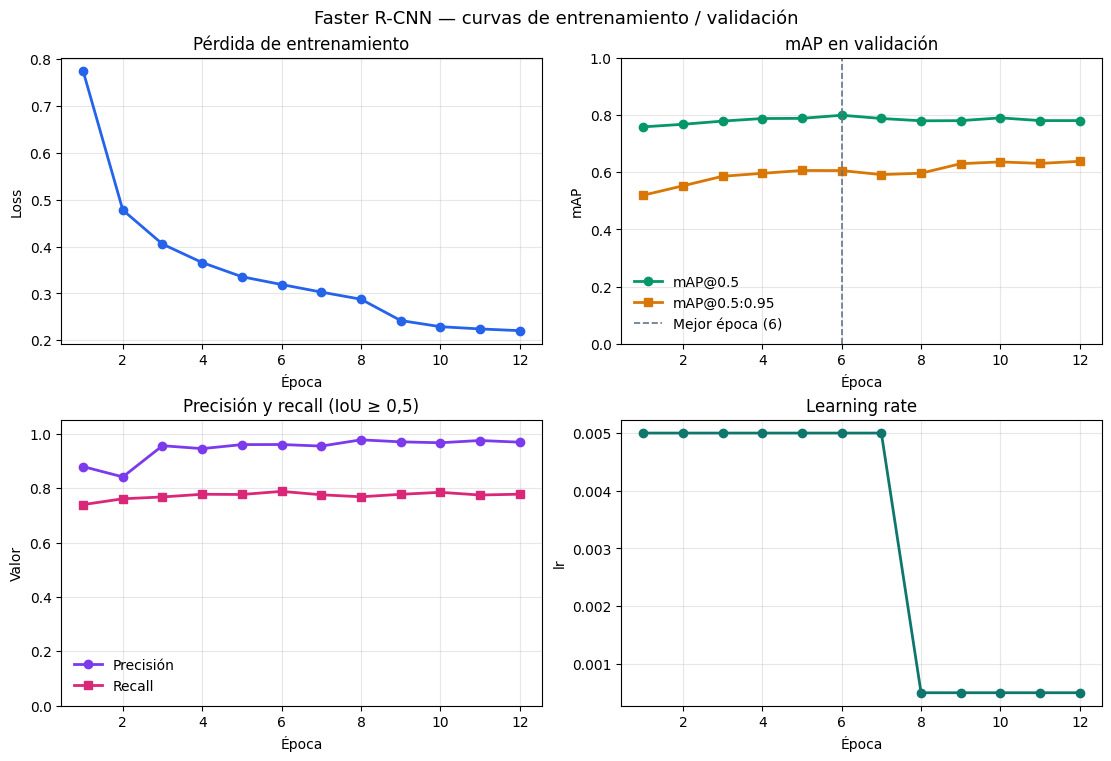

Figura guardada: /content/results/figures/faster_rcnn/curvas_entrenamiento.png


Validación:   0%|          | 0/136 [00:00<?, ?it/s]


Resumen final (mejor checkpoint en validación)


Métrica,Valor
Época (mejor),6
mAP@0.5,0.7996
mAP@0.5:0.95,0.6058
"Precisión (IoU≥0.5, score≥0.5)",0.9602
"Recall (IoU≥0.5, score≥0.5)",0.7880
Latencia (ms/imagen),88.2964
FPS (batch=1),11.3255
Dispositivo,cuda
Checkpoint,/content/results/checkpoints/faster_rcnn/mejor_map50.pt



Resumen gráfico (mejor checkpoint)


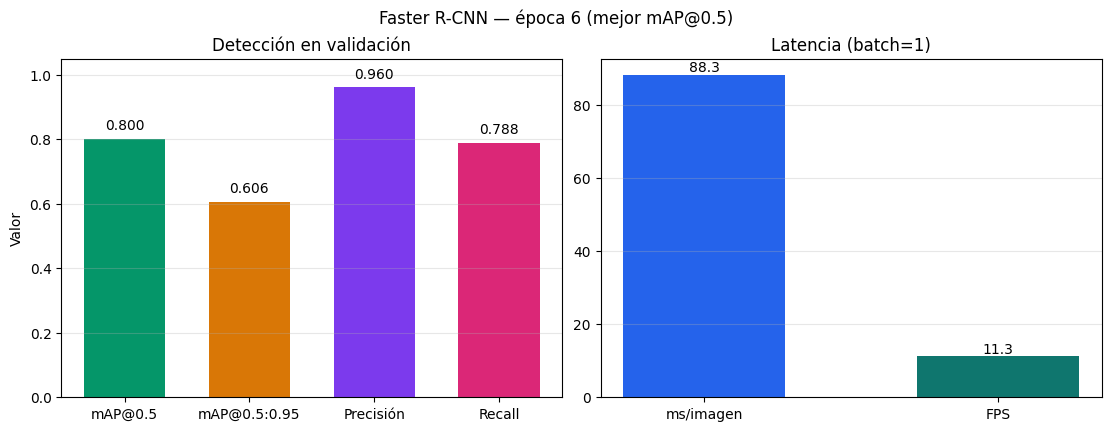

Historial CSV: /content/results/tables/faster_rcnn_historial.csv
Resumen JSON: /content/results/tables/faster_rcnn_resumen_validacion.json
Curvas: /content/results/figures/faster_rcnn/curvas_entrenamiento.png
Resumen gráfico: /content/results/figures/faster_rcnn/resumen_validacion.png


In [6]:
import json
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from torchmetrics.detection import MeanAveragePrecision
from tqdm.auto import tqdm

# =============================================================================
# HIPERPARÁMETROS DE ESTA CELDA (además de HIPERPARAMETROS del modelo)
# =============================================================================
SCORE_EVAL = 0.5  # umbral de score para precisión / recall @ IoU 0.5
IOU_EVAL = 0.5
WARMUP_LATENCIA = 5  # forwards descartados antes de medir ms/imagen
MAX_IMAGENES_LATENCIA = 50  # subset de validación para latencia
# =============================================================================


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def fijar_semilla(semilla: int) -> None:
    random.seed(semilla)
    np.random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)


def iou_cajas(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """IoU entre cajas a (N,4) y b (M,4) en xyxy."""
    if a.numel() == 0 or b.numel() == 0:
        return torch.zeros((a.shape[0], b.shape[0]), device=a.device)
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    lt = torch.max(a[:, None, :2], b[None, :, :2])
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-6)


def precision_recall_imagen(
    cajas_pred: torch.Tensor,
    scores: torch.Tensor,
    cajas_gt: torch.Tensor,
    score_min: float,
    iou_min: float,
) -> tuple[int, int, int]:
    """Devuelve TP, FP, FN con matching guloso a un IoU."""
    keep = scores >= score_min
    cajas_pred = cajas_pred[keep]
    scores = scores[keep]
    if cajas_pred.numel() == 0:
        return 0, 0, int(cajas_gt.shape[0])
    orden = scores.argsort(descending=True)
    cajas_pred = cajas_pred[orden]
    if cajas_gt.numel() == 0:
        return 0, int(cajas_pred.shape[0]), 0

    ious = iou_cajas(cajas_pred, cajas_gt)
    gt_usado = torch.zeros(cajas_gt.shape[0], dtype=torch.bool, device=cajas_gt.device)
    tp = 0
    for i in range(cajas_pred.shape[0]):
        iou_i, j = ious[i].max(dim=0)
        if iou_i >= iou_min and not gt_usado[j]:
            tp += 1
            gt_usado[j] = True
        # si no matchea, es FP (se cuenta al final)
    fp = int(cajas_pred.shape[0]) - tp
    fn = int((~gt_usado).sum().item())
    return tp, fp, fn


@torch.no_grad()
def evaluar_en_cargador(
    modelo: torch.nn.Module,
    cargador,
    dispositivo: torch.device,
    *,
    score_eval: float,
    iou_eval: float,
) -> dict[str, float]:
    modelo.eval()
    metrica_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox")
    metrica_map = metrica_map.to(dispositivo)
    tp_total = fp_total = fn_total = 0

    for imagenes, destinos in tqdm(
        cargador, desc="Validación", leave=False, dynamic_ncols=True
    ):
        imagenes = [img.to(dispositivo) for img in imagenes]
        salidas = modelo(imagenes)

        preds_metric = []
        targets_metric = []
        for salida, destino in zip(salidas, destinos):
            boxes = salida["boxes"].detach()
            scores = salida["scores"].detach()
            labels = salida["labels"].detach()
            preds_metric.append(
                {"boxes": boxes, "scores": scores, "labels": labels}
            )
            gt_boxes = destino["boxes"].to(dispositivo)
            gt_labels = destino["labels"].to(dispositivo)
            targets_metric.append({"boxes": gt_boxes, "labels": gt_labels})

            tp, fp, fn = precision_recall_imagen(
                boxes, scores, gt_boxes, score_eval, iou_eval
            )
            tp_total += tp
            fp_total += fp
            fn_total += fn

        metrica_map.update(preds_metric, targets_metric)

    mapa = metrica_map.compute()
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0.0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0.0

    def _a_float(x) -> float:
        if torch.is_tensor(x):
            if x.numel() == 0 or torch.isnan(x).all():
                return float("nan")
            return float(x.detach().cpu().item() if x.numel() == 1 else x.detach().cpu().mean())
        return float(x)

    return {
        "map_50": _a_float(mapa["map_50"]),
        "map": _a_float(mapa["map"]),
        "precision_50": float(precision),
        "recall_50": float(recall),
        "tp": float(tp_total),
        "fp": float(fp_total),
        "fn": float(fn_total),
    }


@torch.no_grad()
def medir_latencia_ms(
    modelo: torch.nn.Module,
    cargador,
    dispositivo: torch.device,
    *,
    warmup: int,
    max_imagenes: int,
) -> float:
    modelo.eval()
    tiempos: list[float] = []
    vistos = 0
    for imagenes, _destinos in cargador:
        for imagen in imagenes:
            entrada = [imagen.to(dispositivo)]
            if dispositivo.type == "cuda":
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = modelo(entrada)
            if dispositivo.type == "cuda":
                torch.cuda.synchronize()
            dt = time.perf_counter() - t0
            if vistos >= warmup:
                tiempos.append(dt * 1000.0)
            vistos += 1
            if vistos >= warmup + max_imagenes:
                return float(np.mean(tiempos)) if tiempos else float("nan")
    return float(np.mean(tiempos)) if tiempos else float("nan")


def entrenar_una_epoca(
    modelo: torch.nn.Module,
    cargador,
    optimizador: torch.optim.Optimizer,
    dispositivo: torch.device,
    scaler: torch.amp.GradScaler,
    descripcion: str,
) -> float:
    modelo.train()
    suma = 0.0
    n = 0
    usar_amp = dispositivo.type == "cuda"
    barra = tqdm(
        cargador,
        desc=descripcion,
        leave=False,
        dynamic_ncols=True,
    )
    for imagenes, destinos in barra:
        imagenes = [img.to(dispositivo) for img in imagenes]
        destinos = [
            {k: v.to(dispositivo) if torch.is_tensor(v) else v for k, v in d.items()}
            for d in destinos
        ]
        optimizador.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=usar_amp):
            perdidas = modelo(imagenes, destinos)
            total = sum(perdidas.values())
        scaler.scale(total).backward()
        scaler.step(optimizador)
        scaler.update()
        loss_valor = float(total.detach().cpu())
        suma += loss_valor
        n += 1
        barra.set_postfix(loss=f"{suma / n:.4f}", refresh=False)
    barra.close()
    return suma / max(n, 1)


def estilo_tabla(df: pd.DataFrame, formatos: dict | None = None):
    est = df.style.hide(axis="index")
    if formatos:
        est = est.format(formatos)
    return est.set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1e293b"),
                    ("color", "#f8fafc"),
                    ("padding", "8px 12px"),
                    ("text-align", "left"),
                ],
            },
            {
                "selector": "td",
                "props": [("padding", "7px 12px"), ("border-bottom", "1px solid #e2e8f0")],
            },
            {
                "selector": "table",
                "props": [
                    ("border-collapse", "collapse"),
                    ("width", "100%"),
                    ("font-size", "14px"),
                ],
            },
        ]
    )


def graficar_metricas_entrenamiento(
    historial_df: pd.DataFrame,
    ruta_figura: Path,
    epoca_mejor: int | None = None,
) -> None:
    """Curvas por época: loss, mAP, precisión/recall y learning rate."""
    epocas = historial_df["epoca"].to_numpy()
    figura, ejes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

    eje = ejes[0, 0]
    eje.plot(epocas, historial_df["loss_train"], color="#2563eb", marker="o", linewidth=2)
    eje.set_title("Pérdida de entrenamiento")
    eje.set_xlabel("Época")
    eje.set_ylabel("Loss")
    eje.grid(True, alpha=0.3)

    eje = ejes[0, 1]
    eje.plot(
        epocas,
        historial_df["map_50"],
        color="#059669",
        marker="o",
        linewidth=2,
        label="mAP@0.5",
    )
    eje.plot(
        epocas,
        historial_df["map"],
        color="#d97706",
        marker="s",
        linewidth=2,
        label="mAP@0.5:0.95",
    )
    if epoca_mejor is not None:
        eje.axvline(
            epoca_mejor,
            color="#64748b",
            linestyle="--",
            linewidth=1.2,
            label=f"Mejor época ({epoca_mejor})",
        )
    eje.set_title("mAP en validación")
    eje.set_xlabel("Época")
    eje.set_ylabel("mAP")
    eje.set_ylim(0.0, max(1.0, float(historial_df[["map_50", "map"]].max().max()) * 1.05))
    eje.legend(frameon=False)
    eje.grid(True, alpha=0.3)

    eje = ejes[1, 0]
    eje.plot(
        epocas,
        historial_df["precision_50"],
        color="#7c3aed",
        marker="o",
        linewidth=2,
        label="Precisión",
    )
    eje.plot(
        epocas,
        historial_df["recall_50"],
        color="#db2777",
        marker="s",
        linewidth=2,
        label="Recall",
    )
    eje.set_title("Precisión y recall (IoU ≥ 0,5)")
    eje.set_xlabel("Época")
    eje.set_ylabel("Valor")
    eje.set_ylim(0.0, 1.05)
    eje.legend(frameon=False)
    eje.grid(True, alpha=0.3)

    eje = ejes[1, 1]
    eje.plot(epocas, historial_df["lr"], color="#0f766e", marker="o", linewidth=2)
    eje.set_title("Learning rate")
    eje.set_xlabel("Época")
    eje.set_ylabel("lr")
    eje.grid(True, alpha=0.3)

    figura.suptitle("Faster R-CNN — curvas de entrenamiento / validación", fontsize=13)
    figura.savefig(ruta_figura, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figura)


# --- dependencias de celdas anteriores ---
try:
    hp = HIPERPARAMETROS
    modelo_ref = modelo
    dispositivo_ref = dispositivo
except NameError as exc:
    raise RuntimeError(
        "Faltan HIPERPARAMETROS / modelo / dispositivo. Ejecutar la celda del modelo."
    ) from exc

try:
    directorio_datos = DIRECTORIO_DATASET
except NameError:
    directorio_datos = raiz_del_repo() / "dataset"

try:
    crear_fn = crear_cargador
except NameError as exc:
    raise RuntimeError(
        "Falta crear_cargador. Ejecutar la celda Dataset / DataLoader."
    ) from exc

raiz = raiz_del_repo()
directorio_ckpt = raiz / "results" / "checkpoints" / "faster_rcnn"
directorio_tablas = raiz / "results" / "tables"
directorio_figuras = raiz / "results" / "figures" / "faster_rcnn"
directorio_ckpt.mkdir(parents=True, exist_ok=True)
directorio_tablas.mkdir(parents=True, exist_ok=True)
directorio_figuras.mkdir(parents=True, exist_ok=True)
ruta_mejor = directorio_ckpt / "mejor_map50.pt"
ruta_ultimo = directorio_ckpt / "ultimo.pt"
ruta_historial = directorio_tablas / "faster_rcnn_historial.csv"
ruta_resumen = directorio_tablas / "faster_rcnn_resumen_validacion.json"
ruta_figura_metricas = directorio_figuras / "curvas_entrenamiento.png"
ruta_figura_resumen = directorio_figuras / "resumen_validacion.png"

fijar_semilla(int(hp["semilla"]))

cargador_tr = crear_fn(
    directorio_datos,
    "train",
    entrenar=True,
    tamano_lote=int(hp["tamano_lote"]),
)
cargador_va = crear_fn(
    directorio_datos,
    "valid",
    entrenar=False,
    tamano_lote=int(hp["tamano_lote"]),
)

parametros = [p for p in modelo_ref.parameters() if p.requires_grad]
optimizador = torch.optim.SGD(
    parametros,
    lr=float(hp["lr"]),
    momentum=float(hp["momentum"]),
    weight_decay=float(hp["weight_decay"]),
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizador,
    step_size=int(hp["lr_step_size"]),
    gamma=float(hp["lr_gamma"]),
)
scaler = torch.amp.GradScaler("cuda", enabled=(dispositivo_ref.type == "cuda"))

print(f"Dispositivo: {dispositivo_ref}")
print(f"Épocas={hp['epocas']}  batch={hp['tamano_lote']}  lr={hp['lr']}")
print(f"Checkpoints → {directorio_ckpt}")
if dispositivo_ref.type != "cuda":
    print("Aviso: entrenamiento en CPU; en Colab T4 será sustancialmente más rápido.")

historial: list[dict] = []
mejor_map50 = -1.0
epocas_totales = int(hp["epocas"])
barra_epocas = tqdm(
    range(1, epocas_totales + 1),
    desc="Entrenamiento",
    unit="época",
    dynamic_ncols=True,
)

for epoca in barra_epocas:
    t0 = time.perf_counter()
    loss_train = entrenar_una_epoca(
        modelo_ref,
        cargador_tr,
        optimizador,
        dispositivo_ref,
        scaler,
        descripcion=f"Época {epoca}/{epocas_totales} · train",
    )
    metricas = evaluar_en_cargador(
        modelo_ref,
        cargador_va,
        dispositivo_ref,
        score_eval=SCORE_EVAL,
        iou_eval=IOU_EVAL,
    )
    scheduler.step()
    duracion = time.perf_counter() - t0
    fila = {
        "epoca": epoca,
        "loss_train": loss_train,
        "map_50": metricas["map_50"],
        "map": metricas["map"],
        "precision_50": metricas["precision_50"],
        "recall_50": metricas["recall_50"],
        "lr": float(optimizador.param_groups[0]["lr"]),
        "segundos": duracion,
    }
    historial.append(fila)
    barra_epocas.set_postfix(
        loss=f"{loss_train:.4f}",
        mAP50=f"{metricas['map_50']:.3f}",
        P=f"{metricas['precision_50']:.3f}",
        R=f"{metricas['recall_50']:.3f}",
        refresh=False,
    )
    tqdm.write(
        f"Época {epoca}/{epocas_totales}  "
        f"loss={loss_train:.4f}  "
        f"mAP50={metricas['map_50']:.4f}  "
        f"mAP={metricas['map']:.4f}  "
        f"P={metricas['precision_50']:.4f}  "
        f"R={metricas['recall_50']:.4f}  "
        f"({duracion / 60:.1f} min)"
    )

    estado = {
        "epoca": epoca,
        "modelo": modelo_ref.state_dict(),
        "optimizador": optimizador.state_dict(),
        "scheduler": scheduler.state_dict(),
        "hiperparametros": hp,
        "metricas": metricas,
    }
    torch.save(estado, ruta_ultimo)
    if metricas["map_50"] > mejor_map50:
        mejor_map50 = metricas["map_50"]
        torch.save(estado, ruta_mejor)
        tqdm.write(f"  ↑ nuevo mejor mAP@0.5={mejor_map50:.4f} → {ruta_mejor.name}")

df_hist = pd.DataFrame(historial)
df_hist.to_csv(ruta_historial, index=False)
print("\nHistorial por época")
display(
    estilo_tabla(
        df_hist,
        {
            "loss_train": "{:.4f}",
            "map_50": "{:.4f}",
            "map": "{:.4f}",
            "precision_50": "{:.4f}",
            "recall_50": "{:.4f}",
            "lr": "{:.6f}",
            "segundos": "{:.1f}",
        },
    )
)

epoca_mejor_hist = int(df_hist.loc[df_hist["map_50"].idxmax(), "epoca"])
print("\nCurvas de métricas (entrenamiento / validación)")
graficar_metricas_entrenamiento(
    df_hist,
    ruta_figura_metricas,
    epoca_mejor=epoca_mejor_hist,
)
print(f"Figura guardada: {ruta_figura_metricas}")

# Cargar mejor checkpoint para métricas finales + latencia
mejor = torch.load(ruta_mejor, map_location=dispositivo_ref, weights_only=False)
modelo_ref.load_state_dict(mejor["modelo"])
metricas_final = evaluar_en_cargador(
    modelo_ref,
    cargador_va,
    dispositivo_ref,
    score_eval=SCORE_EVAL,
    iou_eval=IOU_EVAL,
)
latencia_ms = medir_latencia_ms(
    modelo_ref,
    cargador_va,
    dispositivo_ref,
    warmup=WARMUP_LATENCIA,
    max_imagenes=MAX_IMAGENES_LATENCIA,
)

resumen = {
    "dispositivo": str(dispositivo_ref),
    "mejor_epoca": int(mejor["epoca"]),
    "checkpoint": str(ruta_mejor),
    "map_50": metricas_final["map_50"],
    "map_50_95": metricas_final["map"],
    "precision_iou50_score": metricas_final["precision_50"],
    "recall_iou50_score": metricas_final["recall_50"],
    "score_eval": SCORE_EVAL,
    "iou_eval": IOU_EVAL,
    "latencia_ms_por_imagen": latencia_ms,
    "fps": (1000.0 / latencia_ms) if latencia_ms and latencia_ms > 0 else float("nan"),
    "hiperparametros": hp,
}
ruta_resumen.write_text(json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8")

print("\nResumen final (mejor checkpoint en validación)")
df_resumen = pd.DataFrame(
    [
        {"Métrica": "Época (mejor)", "Valor": resumen["mejor_epoca"]},
        {"Métrica": "mAP@0.5", "Valor": resumen["map_50"]},
        {"Métrica": "mAP@0.5:0.95", "Valor": resumen["map_50_95"]},
        {
            "Métrica": f"Precisión (IoU≥{IOU_EVAL}, score≥{SCORE_EVAL})",
            "Valor": resumen["precision_iou50_score"],
        },
        {
            "Métrica": f"Recall (IoU≥{IOU_EVAL}, score≥{SCORE_EVAL})",
            "Valor": resumen["recall_iou50_score"],
        },
        {"Métrica": "Latencia (ms/imagen)", "Valor": resumen["latencia_ms_por_imagen"]},
        {"Métrica": "FPS (batch=1)", "Valor": resumen["fps"]},
        {"Métrica": "Dispositivo", "Valor": resumen["dispositivo"]},
        {"Métrica": "Checkpoint", "Valor": resumen["checkpoint"]},
    ]
)
display(
    estilo_tabla(
        df_resumen,
        {
            "Valor": lambda x: (
                f"{x:.4f}" if isinstance(x, float) else str(x)
            )
        },
    )
)

print("\nResumen gráfico (mejor checkpoint)")
etiquetas = ["mAP@0.5", "mAP@0.5:0.95", "Precisión", "Recall"]
valores = [
    resumen["map_50"],
    resumen["map_50_95"],
    resumen["precision_iou50_score"],
    resumen["recall_iou50_score"],
]
colores = ["#059669", "#d97706", "#7c3aed", "#db2777"]
figura_r, (eje_m, eje_l) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
barras = eje_m.bar(etiquetas, valores, color=colores, width=0.65)
eje_m.set_ylim(0.0, 1.05)
eje_m.set_ylabel("Valor")
eje_m.set_title("Detección en validación")
eje_m.grid(True, axis="y", alpha=0.3)
for barra, valor in zip(barras, valores):
    eje_m.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
eje_l.bar(
    ["ms/imagen", "FPS"],
    [resumen["latencia_ms_por_imagen"], resumen["fps"]],
    color=["#2563eb", "#0f766e"],
    width=0.55,
)
eje_l.set_title("Latencia (batch=1)")
eje_l.grid(True, axis="y", alpha=0.3)
for i, valor in enumerate(
    [resumen["latencia_ms_por_imagen"], resumen["fps"]]
):
    eje_l.text(i, valor, f"{valor:.1f}", ha="center", va="bottom", fontsize=10)
figura_r.suptitle(
    f"Faster R-CNN — época {resumen['mejor_epoca']} (mejor mAP@0.5)",
    fontsize=12,
)
figura_r.savefig(ruta_figura_resumen, dpi=150, bbox_inches="tight")
plt.show()
plt.close(figura_r)

print(f"Historial CSV: {ruta_historial}")
print(f"Resumen JSON: {ruta_resumen}")
print(f"Curvas: {ruta_figura_metricas}")
print(f"Resumen gráfico: {ruta_figura_resumen}")
